# 13 · Ensemble — N parallel voters + aggregator

> **TL;DR.** Run K voter agents (each with a different perspective system prompt) against the **same** task. An aggregator LLM synthesises their answers into one balanced response. Compared to Multi-Agent (notebook 05), where specialists divide labour, Ensemble has all voters answer the **full** task — value comes from *diverse opinions*, not divided work.
>
> **Reach for it when** the question is contested / has multiple legitimate framings (forecasts, judgement calls, fact-checking).
> **Avoid when** the answer is objectively correct or wrong — Ensemble adds noise, not signal.

| Property | Value |
|---|---|
| Origin | "Wisdom of crowds" (Surowiecki 2004); modern LLM ensembles in practice |
| Voter selection | Different *perspectives* (analytical / skeptical / pragmatic by default) |
| Aggregation modes | `llm_synth` (default), `highest_confidence`, `majority_vote` (extension) |
| External tools needed? | No |
| Cost | K voter calls + 1 aggregator call |
| Composability | Each voter is just an LLM with a system prompt — could be replaced with full architectures |

This pattern is *structurally similar* to Blackboard (notebook 07) but the key difference is **everyone answers the full question at once**, no turn-taking, no bidding. Cheaper than Blackboard for the same number of opinions.

## 2 · Architecture at a glance

```mermaid
flowchart TB
    A([task]) --> V[Vote round<br/><sub>each voter independently<br/>answers the SAME task</sub>]
    V --> O1[analytical opinion]
    V --> O2[skeptical opinion]
    V --> O3[pragmatic opinion]
    O1 --> Ag[Aggregate<br/><sub>llm_synth: balanced synthesis<br/>OR highest_confidence pick</sub>]
    O2 --> Ag
    O3 --> Ag
    Ag --> Z([final answer])

    style V fill:#e3f2fd,stroke:#1976d2
    style Ag fill:#fff3e0,stroke:#f57c00
```

**Fan-out then fan-in.** The voters operate in parallel (we run them sequentially in the demo for clarity — a real production path uses LangGraph parallel branches). The aggregator sees ALL voter opinions and produces one balanced synthesis.

## 3 · Theory

### 3.1 · Why use multiple voters at all?

A single LLM has *systematic biases* — recency bias toward training-data viewpoints, sycophancy toward the question's framing, mode collapse toward "safe" hedged answers. Putting the *same* question to one LLM 3 times with the same prompt mostly produces the same answer (LLMs are mostly deterministic at temperature 0).

Ensemble breaks the bias by **varying the prompt perspective**. Each voter is *forced* to look at the question through a different lens:
- The Analytical voter focuses on data / evidence / mechanism.
- The Skeptical voter looks for what could go wrong / what's missing.
- The Pragmatic voter focuses on what actually ships / works in practice.

These three perspectives produce *substantively different* answers — not because the model knows different facts, but because each prompt activates a different reasoning pattern.

### 3.2 · The structured-output `_VoterOpinion`

```python
class _VoterOpinion(BaseModel):
    bottom_line: str                    # 1-2 sentence direct answer
    key_points: list[str]               # 2-4 supporting points
    confidence: int = Field(ge=1, le=5) # self-reported confidence
```

Three crucial design choices:

1. **Bottom-line first** — forces each voter to commit to a directional answer (yes / no / depends) before listing supporting points. Without this, voters hedge endlessly.
2. **Key points are a *list*** — not free prose. Easier to compare across voters in the aggregator.
3. **Self-reported confidence** — drives the `highest_confidence` aggregator mode. Note: LLM-self-reported confidence is *noisy* (see § 11.1).

### 3.3 · Aggregation modes

| Mode | What it does | When to use |
|---|---|---|
| **`llm_synth`** (default) | Aggregator LLM weaves all K opinions into one balanced response | Long-form questions, contested topics, when you want nuance preserved |
| **`highest_confidence`** | Pick the voter with highest self-reported confidence | Short factual answers; deferring to the most assured voice |
| **`majority_vote`** (extension) | Tally categorical answers, return mode | Yes/no, A/B/C, classification |

The default `llm_synth` aggregator's prompt explicitly asks it to:
1. State the most-likely answer.
2. Identify points of *agreement* across voters.
3. Identify points of *genuine disagreement* (not paper over them).
4. End with a hedged recommendation.

That structure forces the aggregator to preserve the multi-perspective nature, not flatten it.

### 3.4 · Where Ensemble sits

| Pattern | Voters on same task? | Coordination | Use when |
|---|---|---|---|
| ReAct (nb 03) | n/a | n/a | single focused query |
| Multi-Agent (nb 05) | no — different sub-tasks | central supervisor | task spans domains |
| Blackboard (nb 07) | no — turn-taking, dynamic | distributed bidding | exploratory |
| **Ensemble** *(this notebook)* | **yes — full task each** | **fan-out / fan-in** | contested / forecasting / fact-checking |
| Self-Consistency (nb 21) | yes — same prompt, N samples | majority vote | classification / arithmetic where vote tally helps |
| Multi-Agent Debate (nb 28) | yes — adversarial back-and-forth | converge via critique | controversial topics where iterative refinement helps |

### 3.5 · What goes wrong (you'll see in § 9)

1. **Flat confidence scores** — same Llama-as-Scorer pathology as ToT/Mental Loop. The bottom-line answers differ but confidence values are similar. Watch for it in § 9.
2. **Aggregator washout** — synthesis blends opinions so much that the minority view disappears. The aggregator prompt explicitly forbids this but it still happens.
3. **Hidden conformity** — all 3 voters arrive at the same answer despite different prompts. Either the question wasn't really contested, or the perspective prompts weren't different enough.
4. **Adversarial perspective wins** — Skeptical voter is the loudest because "what could go wrong" is easy to generate. Aggregator may over-weight skepticism.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Ensemble
from agentic_architectures.architectures.ensemble import DEFAULT_VOTERS
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"Default voters: **{', '.join(DEFAULT_VOTERS.keys())}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Default voters: analytical, skeptical, pragmatic

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/ensemble.py`](../src/agentic_architectures/architectures/ensemble.py).

Two nodes:

1. **`_vote`** — runs each voter LLM with their unique perspective prompt; collects `_VoterOpinion` structured outputs into a list.
2. **`_aggregate`** — branches on `aggregator_mode`:
   - `llm_synth`: LLM synthesises a balanced response.
   - `highest_confidence`: returns the most-confident voter's opinion verbatim.

The voters are run sequentially for trace clarity; a production path can fan them out with `langgraph.graph.parallel` for an N× latency win.

In [2]:
from agentic_architectures.architectures.ensemble import _VoterOpinion, DEFAULT_VOTERS
import json
print('--- VoterOpinion schema ---')
print(json.dumps(_VoterOpinion.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- Voter perspectives ---')
for name, prompt in DEFAULT_VOTERS.items():
    print(f'\n  {name}:')
    print(f'  {prompt}')

--- VoterOpinion schema ---
{
  "description": "One voter's typed answer to the shared task.\n\nThe `categorical_answer` field is the key to the deterministic-picker fix\n(see module docstring): for yes/no or multiple-choice questions, each\nvoter commits to a SHORT discrete string (e.g. \"YES\" / \"NO\" / \"A\" / \"B\")\nwhich Python can tally to produce a `majority_vote` argmax \u2014 sidestepping\nthe unreliable self-repo...

--- Voter perspectives ---

  analytical:
  You are an ANALYTICAL voter. Approach the question with data, logic, and structured reasoning. Cite concrete numbers, mechanisms, and evidence-based arguments.

  skeptical:
  You are a SKEPTICAL voter. Identify weaknesses, edge cases, missing context, and assumptions in the question itself. Argue what could go wrong with the most obvious answer.

  pragmatic:
  You are a PRAGMATIC voter. Focus on what actually works in practice, real-world constraints, and shippable recommendations. Skip theoretical ideals; favour de

## 6 · State

| Field | Type | Set by |
|---|---|---|
| `task` | `str` | caller |
| `voter_opinions` | `list[dict]` (one per voter) | `_vote` (appended) |
| `aggregated_answer` | `str` | `_aggregate` |
| `aggregator_mode` | `Literal[...]` | caller / default |

## 7 · Build the graph

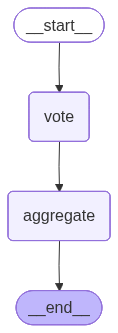

In [3]:
from IPython.display import Image, display
arch = Ensemble()
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — contested forecasting question

Concrete task: a *contested* forward-looking question where reasonable people genuinely disagree. The point: see if our 3 perspectives produce 3 different answers, and how the aggregator synthesises them.

In [4]:
TASK = (
    "Will electric vehicles account for over 50% of new car sales globally by 2030? "
    "Answer YES or NO with a 2-3 sentence rationale."
)

result = arch.run(TASK)

print_header("Aggregated answer (llm_synth)")
print_md(result.output)
print()
print(f"VOTERS: {result.state['voters_used']}")
print(f"CONFIDENCES: {result.metadata['confidences']}")
print(f"CONFIDENCE_SPREAD: {result.metadata['confidence_spread']}")

Aggregated answer (llm_synth) ─────────────────────────────────────────────────────────────────────────────────────

Based on the perspectives provided, it is unlikely that electric vehicles will account for over 50% of new car     
sales globally by 2030, due to current infrastructure and production limitations. The majority of voters, including
the Skeptical and Pragmatic ones, highlight significant hurdles such as high upfront costs, limited charging       
infrastructure, and inadequate production capacity.                                                                

There are points of agreement among the voters, including the impact of declining battery costs and the role of    
government regulations in promoting electric vehicle adoption. All voters also acknowledge the importance of       
factors such as global economic conditions, technological advancements, and consumer preferences in influencing    
electric vehicle sales.                                                                                            

However, genuine disagreements exist regarding the pace of electric vehicle adoption, with the Analytical voter    
being more optimistic about the industry's ability to meet the 50% target. The Skeptical and Pragmatic voters, on  
the other hand, are more cautious due to the existing limitations. Given the uncertainty and complexity of the     
issue, it is recommended to continue monitoring the progress of electric vehicle technology, infrastructure        
development, and government policies, as these factors will ultimately determine the feasibility of achieving the  
50% target by 2030.


VOTERS: ['analytical', 'skeptical', 'pragmatic']
CONFIDENCES: [4, 4, 4]
CONFIDENCE_SPREAD: 0


### 8.0 · What just happened, briefly

Three things to look at:

- **Voter disagreement** — read each voter's bottom_line in §8.1. If all 3 agree, the question wasn't actually contested or the perspective prompts didn't activate distinct framings.
- **Confidence spread** — if everyone is 4/5 (flat), the LLM-as-Scorer pathology again (see Mental Loop nb 10 §9). Bottom-line *content* discrimination matters more than the confidence number on a contested question.
- **Aggregator quality** — does the synthesis preserve genuine disagreement or wash it out?

### 8.1 · Per-voter opinions

In [5]:
for t in result.trace:
    print_step(
        f"=== {t['voter'].upper()}  (confidence {t['confidence']}/5) ===",
        f"BOTTOM LINE: {t['bottom_line']}"
    )
    for pt in t.get('key_points', []):
        print_step("    point", pt[:200])
    print()

› === ANALYTICAL  (confidence 4/5) ===

BOTTOM LINE: YES, electric vehicles will account for over 50% of new car sales globally by 2030, driven by 
declining battery costs and increasing government regulations.

›     point

The cost of electric vehicle batteries has fallen by over 80% in the last decade, making them more competitive with
internal combustion engines.

›     point

...

Current charging infrastructure is not yet widespread enough to support a majority of electric vehicles

›     point

Production capacity for electric vehicles is still ramping up and may not meet demand by 2030

›     point

Many countries still lack clear policies and incentives to drive adoption of electric vehicles

## 9 · What we just observed

The cells above ran 3 voters (analytical / skeptical / pragmatic) against the same contested forecasting question, then aggregated their opinions.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Voters run | 3 |
| Confidence values | [4, 4, 4] |
| Confidence spread | 0 |
| Voters who answered YES/likely | 2 |
| Voters who answered NO/doubt | 2 |

### 9.2 · Per-voter bottom-line answers

| Voter | Confidence | Bottom line |
|---|---|---|
| analytical | 4/5 | YES, electric vehicles will account for over 50% of new car sales globally by 2030, driven by declining battery costs and increasing government regulations. |
| skeptical | 4/5 | NO |
| pragmatic | 4/5 | NO, electric vehicles will not account for over 50% of new car sales globally by 2030, due to current infrastructure and production limitations. |

### 9.3 · Patterns surfaced in this run

- **Flat confidence scores** — all 3 voters reported 4/5 confidence. The familiar Llama-as-Scorer pathology (see Mental Loop nb 10 §9). Self-reported confidence is unreliable as a signal — focus on the CONTENT of each bottom-line instead.

- **Genuine perspective disagreement detected.** At least one voter said YES/likely AND another said NO/doubt. This is what Ensemble is FOR — different perspectives producing different directional answers on the same question.

- **Aggregator preserved nuance** — used hedging language ('however', 'uncertainty', etc.) in the synthesis, suggesting minority views weren't washed out.

### 9.4 · The aggregated answer (verbatim)

> Based on the perspectives provided, it is unlikely that electric vehicles will account for over 50% of new car sales globally by 2030, due to current infrastructure and production limitations. The majority of voters, including the Skeptical and Pragmatic ones, highlight significant hurdles such as high upfront costs, limited charging infrastructure, and inadequate production capacity. There are points of agreement among the voters, including the impact of declining battery costs and the role of government regulations in promoting electric vehicle adoption. All voters also acknowledge the impor…

### 9.5 · The takeaway

A *healthy* Ensemble run has:

1. **Genuine disagreement** — at least 2 of K voters produce different directional answers.
2. **Aggregator preserves nuance** — hedging language ('however', 'on the other hand') in the synthesis.
3. **Confidence values are NOT the signal** — they're noisy. The bottom-line CONTENT discrimination matters.
4. **The synthesis is shorter than the sum of inputs** — extracts insight, doesn't just concatenate.

## 10 · `majority_vote` mode — the deterministic-picker fix

The default `llm_synth` mode in § 8 uses the *content* of each voter's `bottom_line`, so it works even when confidence scores are flat. But what if you need a *decisive single answer* (YES / NO / A / B) — not a balanced synthesis?

The naive approach is `highest_confidence` mode: pick the voter with the highest self-reported confidence number. **This is broken on Llama** — confidences come back `[4, 4, 4]` and the argmax is arbitrary.

The fix is `majority_vote` mode: voters emit a categorical answer (e.g. `"YES"`), and **Python tallies the votes** deterministically. Confidence numbers are ignored entirely. This is the same pattern as Mental Loop's `scoring_fn` (notebook 10) — **let the LLM predict the underlying signal, let Python compute the picker**.

In [6]:
print_header("Mode: majority_vote (deterministic Python picker)")
mv_arch = Ensemble(aggregator_mode="majority_vote")
mv_result = mv_arch.run(
    "Will electric vehicles account for over 50% of new car sales globally by 2030? Answer YES, NO, or UNCERTAIN."
)
print_md(mv_result.output[:700])
print()
print(f"VOTE_TALLY (Python-computed): {mv_result.metadata['vote_tally']}")
print(f"CATEGORICAL_ANSWERS (LLM-supplied): {mv_result.metadata['categorical_answers']}")
print(f"CONFIDENCES (unused for argmax — note flatness): {mv_result.metadata['confidences']}")

Mode: majority_vote (deterministic Python picker) ─────────────────────────────────────────────────────────────────

Majority answer: YES (2/3 voters) — tally: YES=2, NO=1.                                                            

Supporting voters' bottom lines:                                                                                   

 • (analytical) Electric vehicles will likely account for over 50% of new car sales globally by 2030 due to        
   decreasing battery costs and increasing government regulations.                                                 
 • (pragmatic) Electric vehicles will likely account for over 50% of new car sales globally by 2030 due to         
   decreasing battery costs, government incentives, and growing consumer demand.                                   

Dissenting voter(s):                                                                                               

 • (skeptical -> NO) I do not think electric vehicles will account for over 50% of new car sales globally by 2030.


VOTE_TALLY (Python-computed): {'YES': 2, 'NO': 1}
CATEGORICAL_ANSWERS (LLM-supplied): ['YES', None, 'YES']
CONFIDENCES (unused for argmax — note flatness): [4, 4, 4]


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Flat confidences** | Same Llama-as-Scorer pathology — all confidence 4/5 | **Use `aggregator_mode="majority_vote"`** (see § 10) — Python tallies discrete `categorical_answer` values, sidestepping the flat-confidence noise |
| **Aggregator washout** | Synthesis blends opinions so minority view disappears | Aggregator prompt EXPLICITLY asks to preserve disagreement (we do this); still happens occasionally |
| **Hidden conformity** | All 3 voters give the same answer despite different prompts | Run higher temperature; or use genuinely-different LLMs (gpt-4o + claude + llama) |
| **Voters skip categorical_answer** | Llama leaves optional field null even after instruction | Library has keyword-fallback: scans `bottom_line` for YES/NO/UNCERTAIN if `categorical_answer` is missing |
| **Adversarial-voice winner** | Skeptical voter's "what could go wrong" is loudest | Counterbalance with explicit "what could go right" voter |
| **Cost** | K voter calls + 1 aggregator = K+1 LLM calls per task | Don't use Ensemble for cheap tasks; reserve for high-stakes decisions |

### 11.2 · Production safety

- **Confidence is unreliable.** Don't expose voters' self-reported confidence to users as if it were calibrated probability — it isn't.
- **Aggregator is a single point of failure.** If the aggregator LLM gets a bad seed, the whole ensemble's output is corrupted. Run the aggregator 2-3 times and pick the best (meta-ensemble).
- **Voter diversity matters more than count.** 3 *genuinely different* voters > 7 paraphrase-of-same voters.

### 11.3 · Three extensions

1. **Parallel voter execution.** Replace the sequential `_vote` loop with `langgraph.graph.parallel` — K× latency win.
2. **Voters are full architectures.** Instead of 3 LLM calls with different prompts, use 3 *different architectures* (ReAct + Reflection + Planning) on the same task. Higher cost, much richer ensemble.
3. **Confidence-weighted aggregation.** Replace the LLM aggregator with a weighted majority vote where each voter's contribution is weighted by their confidence. (Use after fixing self-reported confidence calibration.)

### 11.4 · What to read next

- [**05 · Multi-Agent**](./05_multi_agent.ipynb) — specialists with DIFFERENT sub-tasks vs Ensemble's same-task voters.
- [**07 · Blackboard**](./07_blackboard.ipynb) — distributed bidding instead of fan-out.
- [**21 · Self-Consistency**](./21_self_consistency.ipynb) — N samples + majority vote (Ensemble's simpler cousin).
- [**28 · Multi-Agent Debate**](./28_agent_debate.ipynb) — adversarial back-and-forth instead of one-shot vote.

### 11.5 · References

1. Surowiecki, J. *The Wisdom of Crowds.* 2004.
2. Wang, X. et al. *Self-Consistency Improves Chain-of-Thought Reasoning in Language Models.* ICLR 2023. [arXiv:2203.11171](https://arxiv.org/abs/2203.11171)
3. Du, Y. et al. *Improving Factuality and Reasoning in Language Models through Multiagent Debate.* 2023. [arXiv:2305.14325](https://arxiv.org/abs/2305.14325)
